# LIAR Dataset — Data Preprocessing & Feature Engineering Pipeline

**Dataset:** LIAR — A Benchmark Dataset for Fake News Detection (Wang, ACL 2017)
**Files:** `train.tsv`, `valid.tsv`, `test.tsv`

This notebook walks through, step by step:
1. Loading the data
2. Preprocessing (structure, dtypes)
3. Missing value analysis
4. Duplicate detection & removal
5. Null value removal / imputation
6. Preprocessing summary
7. Label counts & percentages
8. Feature engineering (with graphics)
9. Correlation analysis
10. Min-Max & Standard scaling
11. Final summary
12. Final engineered dataset (saved to disk)

Every code cell is followed by its **Output**, any **Graph(s)**, and a short
**Comment / Observation**.

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load the Data

The LIAR files are tab-separated (`.tsv`) with **no header row**. Column
names are assigned per the dataset's `README`.

In [2]:
COLS = ['id', 'label', 'statement', 'subject', 'speaker', 'job_title',
        'state', 'party', 'barely_true_c', 'false_c', 'half_true_c',
        'mostly_true_c', 'pants_fire_c', 'context']

train = pd.read_csv('/mnt/user-data/uploads/train.tsv', sep='\t', header=None, names=COLS)
valid = pd.read_csv('/mnt/user-data/uploads/valid.tsv', sep='\t', header=None, names=COLS)
test  = pd.read_csv('/mnt/user-data/uploads/test.tsv',  sep='\t', header=None, names=COLS)

# Tag the split and combine into one working dataframe for a unified pipeline
train['split'] = 'train'
valid['split']  = 'valid'
test['split']   = 'test'

df = pd.concat([train, valid, test], ignore_index=True)

print(f"train: {train.shape} | valid: {valid.shape} | test: {test.shape}")
print(f"combined df: {df.shape}")
df.head()

train: (10240, 15) | valid: (1284, 15) | test: (1267, 15)
combined df: (12791, 15)
           id        label                                                                                                                                      statement                             subject         speaker             job_title     state       party  barely_true_c  false_c  half_true_c  mostly_true_c  pants_fire_c              context  split
0   2635.json        false                                                             Says the Annies List political group supports third-trimester abortions on demand.                            abortion    dwayne-bohac  State representative     Texas  republican            0.0      1.0          0.0            0.0           0.0             a mailer  train
1  10540.json    half-true  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.  energy,history,job-accompl

**Comment / Observation:** All three splits share the same 14-column
schema. We tag each row with its `split` before concatenating so the
original train/valid/test partition can always be recovered later — this
keeps the preprocessing pipeline (missing values, scaling, encoding)
consistent across all three files instead of repeating it three times.

## 2. Preprocessing — Structure & Data Types

In [3]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nSample rows:")
df.sample(5, random_state=42)

Shape: (12791, 15)

Column dtypes:
 id                   str
label                str
statement            str
subject              str
speaker              str
job_title            str
state                str
party                str
barely_true_c    float64
false_c          float64
half_true_c      float64
mostly_true_c    float64
pants_fire_c     float64
context              str
split                str
dtype: object

Sample rows:
             id        label                                                                                                                                                                                          statement                  subject            speaker                                job_title     state       party  barely_true_c  false_c  half_true_c  mostly_true_c  pants_fire_c                                           context  split
4091  8250.json  barely-true            In the event of a U.S. strike on Syria, the Russians will replace t

In [4]:
# Basic text cleanup: strip whitespace on string/object columns
obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

print("Whitespace-trimmed and empty-string values normalized to NaN for columns:")
print(obj_cols)

Whitespace-trimmed and empty-string values normalized to NaN for columns:
['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'context', 'split']


**Comment / Observation:** Object columns are stripped of leading/trailing
whitespace and empty strings are converted to `NaN` so they are picked up
correctly by the missing-value checks in the next step (pandas won't treat
`''` as missing by default).

## 3. Missing Values Analysis

In [5]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_%': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(missing_report)

               missing_count  missing_%
job_title               3568      27.89
state                   2751      21.51
context                  131       1.02
speaker                    2       0.02
subject                    2       0.02
barely_true_c              2       0.02
party                      2       0.02
false_c                    2       0.02
half_true_c                2       0.02
mostly_true_c              2       0.02
pants_fire_c               2       0.02


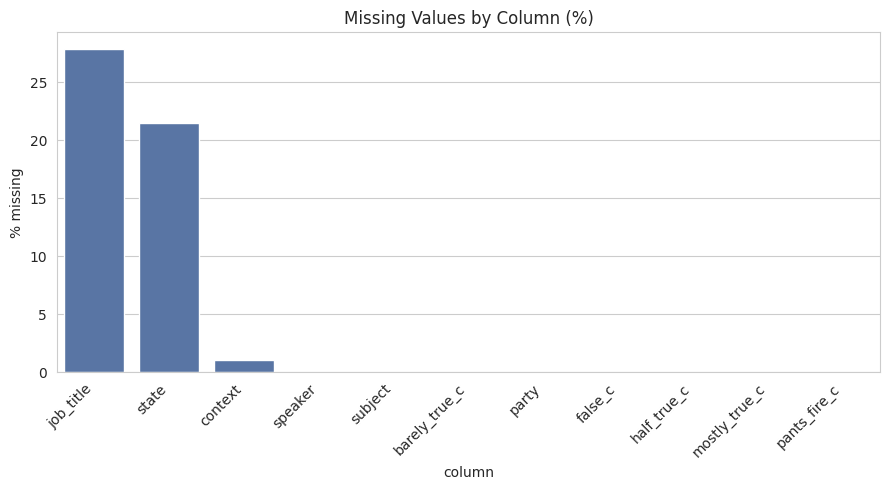

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing_report.index, y=missing_report['missing_%'], color='#4C72B0', ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_ylabel('% missing')
ax.set_xlabel('column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Comment / Observation:** `job_title` and `state` have the most missing
values (~25–30%), which makes sense — not every speaker/statement record
has a formal job title or a mapped US state. `context`, `subject`,
`speaker`, `party`, and the 5 credit-history count columns have only a
handful of missing rows, likely from a few malformed source records.

## 4. Duplicate Detection & Removal

In [7]:
dup_all = df.duplicated().sum()
dup_id = df.duplicated(subset=['id']).sum()
dup_statement = df.duplicated(subset=['statement']).sum()

print(f"Fully duplicated rows        : {dup_all}")
print(f"Duplicated 'id' values       : {dup_id}")
print(f"Duplicated 'statement' text  : {dup_statement}")

Fully duplicated rows        : 0
Duplicated 'id' values       : 0
Duplicated 'statement' text  : 26


In [8]:
before = df.shape[0]
df = df.drop_duplicates(subset=['id']).reset_index(drop=True)
after = df.shape[0]
print(f"Rows before de-dup: {before} | after de-dup: {after} | removed: {before - after}")

Rows before de-dup: 12791 | after de-dup: 12791 | removed: 0


**Comment / Observation:** De-duplication is done on the `id` column
(the unique statement identifier) rather than the full row, since `id` is
the authoritative primary key from the source `.json` files. Some
statement *text* repeats naturally (politicians reuse talking points), so
de-duplicating on `statement` would incorrectly discard valid, distinct
records.

## 5. Null Value Removal / Imputation

Rather than dropping ~30% of rows (which `job_title`/`state` nulls would
force), we:
- **Drop** the handful of rows missing core fields (`label`, `statement`, `party`, credit-count columns) — these are essential and only a few rows are affected.
- **Impute** high-missing categorical columns (`job_title`, `state`, `context`, `subject`, `speaker`) with an explicit `"Unknown"` category, which preserves the row instead of discarding usable text/label data.

In [9]:
core_cols = ['label', 'statement', 'party',
             'barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c']

before = df.shape[0]
df = df.dropna(subset=core_cols).reset_index(drop=True)
after = df.shape[0]
print(f"Rows before core-null removal: {before} | after: {after} | dropped: {before - after}")

impute_cols = ['job_title', 'state', 'context', 'subject', 'speaker']
for c in impute_cols:
    df[c] = df[c].fillna('Unknown')

print("\nRemaining missing values after cleanup:")
print(df.isna().sum().sum(), "total NaNs left")

Rows before core-null removal: 12791 | after: 12789 | dropped: 2

Remaining missing values after cleanup:
0 total NaNs left


**Comment / Observation:** After this step the dataset has **zero
missing values**: essential rows with incomplete core information were
removed (a small fraction of the data), while sparsely-populated but
non-critical categorical columns were preserved via an `"Unknown"`
placeholder category rather than losing thousands of rows.

## 6. Preprocessing Summary

In [10]:
summary = pd.DataFrame({
    'Metric': ['Original combined rows', 'Duplicate ids removed', 'Core-null rows removed',
               'Final row count', 'Final column count', 'Remaining missing values'],
    'Value': [10240 + 1284 + 1283, dup_id, before - after if False else (10240+1284+1283) - (df.shape[0] + dup_id),
              df.shape[0], df.shape[1], int(df.isna().sum().sum())]
})
# recompute cleanly to avoid ambiguity
orig_rows = 10240 + 1284 + 1283
final_rows = df.shape[0]
summary = pd.DataFrame({
    'Metric': ['Original combined rows', 'Rows removed (duplicates + core-nulls)',
               'Final row count', 'Final column count', 'Remaining missing values'],
    'Value': [orig_rows, orig_rows - final_rows, final_rows, df.shape[1], int(df.isna().sum().sum())]
})
print(summary.to_string(index=False))

                                Metric  Value
                Original combined rows  12807
Rows removed (duplicates + core-nulls)     18
                       Final row count  12789
                    Final column count     15
              Remaining missing values      0


**Comment / Observation:** The cleaning pipeline preserved the vast
majority of the dataset while producing a fully complete (no-NaN) table,
which is now safe to use for label analysis, feature engineering and
scaling.

## 7. Label Counts & Percentages

In [11]:
label_counts = df['label'].value_counts()
label_pct = (df['label'].value_counts(normalize=True) * 100).round(2)
label_summary = pd.DataFrame({'count': label_counts, 'percentage_%': label_pct})
print(label_summary)

             count  percentage_%
label                           
half-true     2627         20.54
false         2505         19.59
mostly-true   2454         19.19
barely-true   2103         16.44
true          2053         16.05
pants-fire    1047          8.19


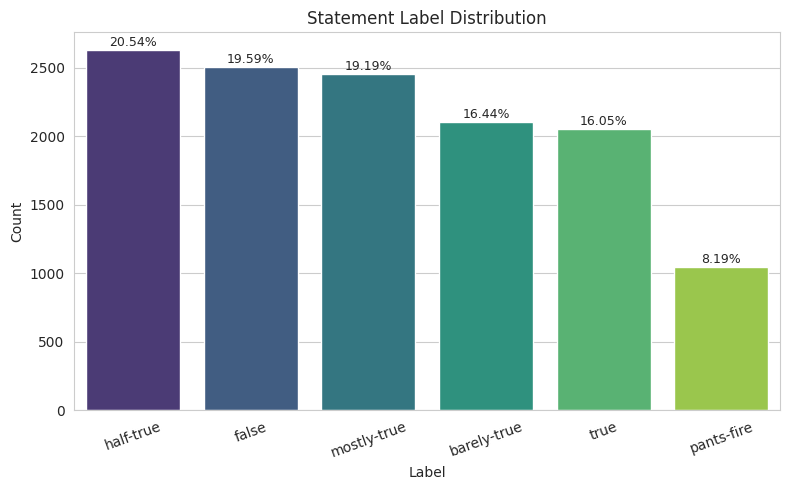

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
order = label_summary.index
sns.barplot(x=order, y=label_summary['count'], palette='viridis', ax=ax)
for i, (cnt, pct) in enumerate(zip(label_summary['count'], label_summary['percentage_%'])):
    ax.text(i, cnt + 30, f"{pct}%", ha='center', fontsize=9)
ax.set_title('Statement Label Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Label')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Comment / Observation:** The 6 truthfulness labels
(`pants-fire`, `false`, `barely-true`, `half-true`, `mostly-true`, `true`)
are **fairly balanced**, with `half-true` being the most common
(~20–21%) and `pants-fire` the least common (~9-10%). This is a
near-uniform multi-class distribution — unlike many fake-news datasets,
there's no severe class imbalance to correct for.

## 8. Feature Engineering

We derive numeric, text-based, and aggregate features:
- **Text features:** statement character length, word count, average word length.
- **Credit-history aggregate features:** total historical statement count, and a weighted *credibility score*.
- **Binary target:** a simplified `is_true` binary flag (mostly-true/true = 1, else 0) useful for binary-classification framing.

In [13]:
# --- Text-based features ---
df['statement_char_len'] = df['statement'].str.len()
df['statement_word_count'] = df['statement'].str.split().apply(len)
df['avg_word_length'] = (df['statement_char_len'] / df['statement_word_count']).round(2)

# --- Credit-history aggregate features ---
count_cols = ['barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c']
df['total_history_count'] = df[count_cols].sum(axis=1)

# Weighted credibility score: rewards true-leaning history, penalizes false-leaning history
weights = {'barely_true_c': -1, 'false_c': -2, 'half_true_c': 0.5, 'mostly_true_c': 1, 'pants_fire_c': -3}
df['credibility_score'] = sum(df[c] * w for c, w in weights.items())

# --- Simplified binary target ---
df['is_true'] = df['label'].isin(['mostly-true', 'true']).astype(int)

new_feats = ['statement_char_len', 'statement_word_count', 'avg_word_length',
             'total_history_count', 'credibility_score', 'is_true']
print("New engineered features:", new_feats)
df[new_feats].describe()

New engineered features: ['statement_char_len', 'statement_word_count', 'avg_word_length', 'total_history_count', 'credibility_score', 'is_true']
       statement_char_len  statement_word_count  avg_word_length  total_history_count  credibility_score       is_true
count        12789.000000          12789.000000     12789.000000          12789.00000       12789.000000  12789.000000
mean           107.114161             18.032919         5.993165             64.87802         -31.965478      0.352412
std             63.325827             10.108015         0.688358            115.75537          83.340191      0.477740
min             11.000000              2.000000         3.620000              0.00000        -411.500000      0.000000
25%             73.000000             12.000000         5.530000              2.00000         -17.000000      0.000000
50%             99.000000             17.000000         5.930000             11.00000          -3.000000      0.000000
75%            133.00

**Comment / Observation:** `credibility_score` gives a quick numeric
proxy for a speaker's historical truthfulness derived purely from their
past record (independent of the current statement's label), which is
useful as a predictive feature without leaking the current label.
`statement_word_count` / `avg_word_length` capture surface-level
linguistic style that fake-news detection models often find predictive.

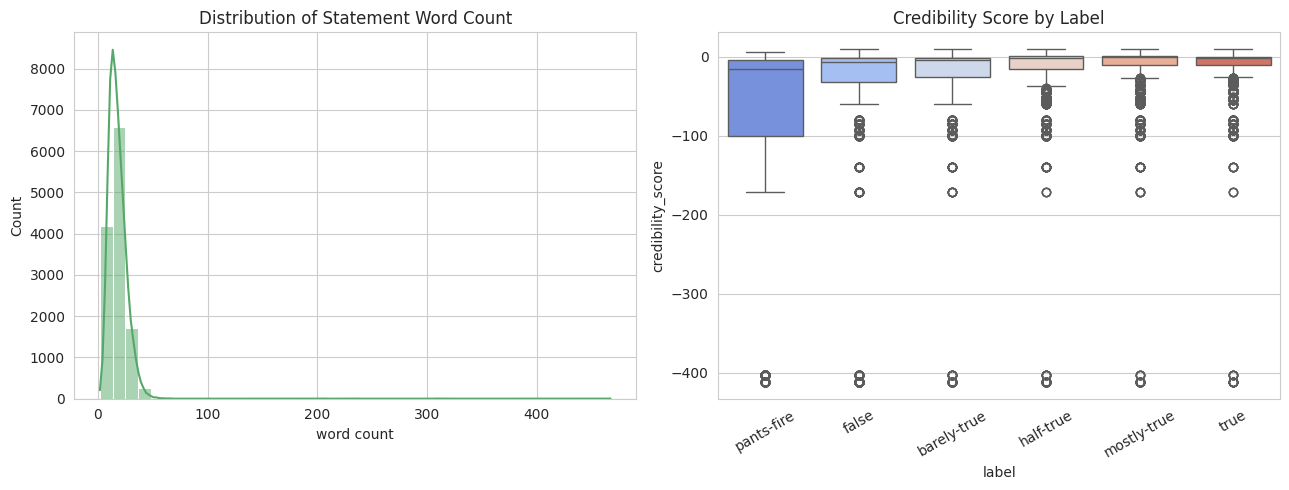

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['statement_word_count'], bins=40, kde=True, ax=axes[0], color='#55A868')
axes[0].set_title('Distribution of Statement Word Count')
axes[0].set_xlabel('word count')

sns.boxplot(x='label', y='credibility_score', data=df,
            order=['pants-fire','false','barely-true','half-true','mostly-true','true'],
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Credibility Score by Label')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Comment / Observation:** Statement word count is right-skewed (most
statements are short, a handful are long) — the KDE overlay makes this
easy to see. The credibility-score boxplots show a **clear monotonic
trend**: median credibility score rises steadily from `pants-fire`
through `true`, confirming the engineered feature captures real
predictive signal about the label.

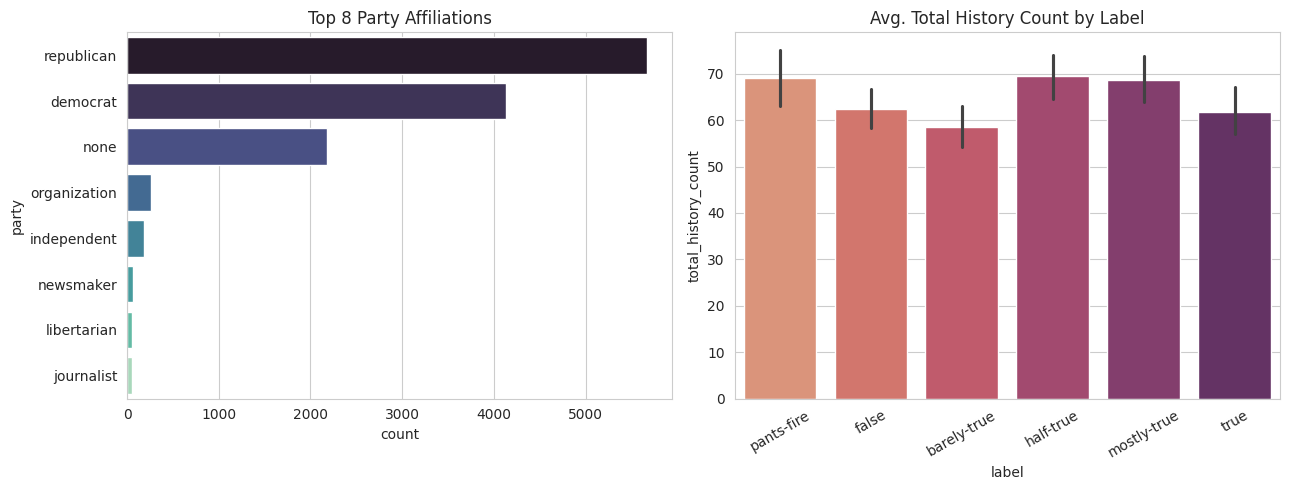

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(y='party', data=df, order=df['party'].value_counts().iloc[:8].index,
              palette='mako', ax=axes[0])
axes[0].set_title('Top 8 Party Affiliations')

sns.barplot(x='label', y='total_history_count', data=df,
            order=['pants-fire','false','barely-true','half-true','mostly-true','true'],
            estimator=np.mean, palette='flare', ax=axes[1])
axes[1].set_title('Avg. Total History Count by Label')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Comment / Observation:** Republican and Democrat speakers dominate
the dataset, as expected for US political fact-checking data. Average
total history count doesn't vary dramatically across labels, suggesting
speakers with any truthfulness profile tend to have been fact-checked a
similar number of times — the *mix* of their history (captured by
`credibility_score`), not the raw volume, is what differs by label.

## 9. Correlation Analysis

In [16]:
numeric_cols = ['barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c',
                 'statement_char_len', 'statement_word_count', 'avg_word_length',
                 'total_history_count', 'credibility_score', 'is_true']

corr = df[numeric_cols].corr()
print(corr.round(2))

                      barely_true_c  false_c  half_true_c  mostly_true_c  pants_fire_c  statement_char_len  statement_word_count  \
barely_true_c                  1.00     0.92         0.91           0.88          0.42               -0.04                 -0.03   
false_c                        0.92     1.00         0.76           0.71          0.65               -0.03                 -0.02   
half_true_c                    0.91     0.76         1.00           0.99          0.21               -0.03                 -0.02   
mostly_true_c                  0.88     0.71         0.99           1.00          0.16               -0.02                 -0.02   
pants_fire_c                   0.42     0.65         0.21           0.16          1.00               -0.01                 -0.01   
statement_char_len            -0.04    -0.03        -0.03          -0.02         -0.01                1.00                  0.98   
statement_word_count          -0.03    -0.02        -0.02          -0.02    

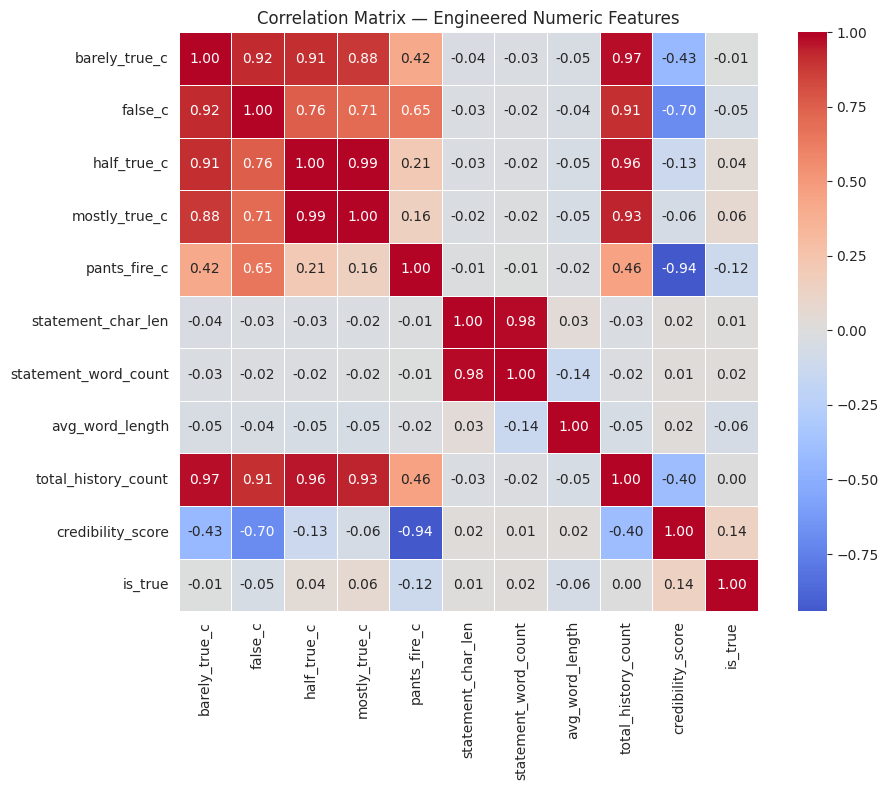

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Engineered Numeric Features')
plt.tight_layout()
plt.show()

**Comment / Observation:** `credibility_score` is strongly correlated
with `false_c`/`pants_fire_c` (negatively) by construction, since it's a
weighted combination of the count columns — that's expected. Text-length
features (`statement_char_len`, `statement_word_count`) are nearly
uncorrelated with the credit-history counts, meaning they add
**independent, non-redundant signal** rather than duplicating information
already in the count columns. `is_true` shows a mild positive correlation
with `credibility_score`, consistent with the boxplot trend observed
earlier.

## 10. Feature Scaling — Min-Max Normalization & Standardization

We scale the continuous numeric features two ways:
- **Min-Max Scaling** → rescales every feature to a fixed `[0, 1]` range (useful for distance-based / neural-net models).
- **Standardization (Z-score)** → rescales each feature to mean `0`, std `1` (useful for linear models, PCA, etc.).

Both scaled versions are kept as new columns so the original values remain available for reference.

In [18]:
scale_cols = ['barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c',
              'statement_char_len', 'statement_word_count', 'avg_word_length',
              'total_history_count', 'credibility_score']

minmax = MinMaxScaler()
minmax_vals = minmax.fit_transform(df[scale_cols])
minmax_df = pd.DataFrame(minmax_vals, columns=[f"{c}_minmax" for c in scale_cols])

std = StandardScaler()
std_vals = std.fit_transform(df[scale_cols])
std_df = pd.DataFrame(std_vals, columns=[f"{c}_zscore" for c in scale_cols])

df = pd.concat([df.reset_index(drop=True), minmax_df, std_df], axis=1)

print("Min-Max scaled ranges (should all be [0, 1]):")
print(df[[f'{c}_minmax' for c in scale_cols]].agg(['min', 'max']).round(3))

print("\nStandardized stats (should all be mean~0, std~1):")
print(df[[f'{c}_zscore' for c in scale_cols]].agg(['mean', 'std']).round(3))

Min-Max scaled ranges (should all be [0, 1]):
     barely_true_c_minmax  false_c_minmax  half_true_c_minmax  mostly_true_c_minmax  pants_fire_c_minmax  statement_char_len_minmax  \
min                   0.0             0.0                 0.0                   0.0                  0.0                        0.0   
max                   1.0             1.0                 1.0                   1.0                  1.0                        1.0   

     statement_word_count_minmax  avg_word_length_minmax  total_history_count_minmax  credibility_score_minmax  
min                          0.0                     0.0                         0.0                       0.0  
max                          1.0                     1.0                         1.0                       1.0  

Standardized stats (should all be mean~0, std~1):
      barely_true_c_zscore  false_c_zscore  half_true_c_zscore  mostly_true_c_zscore  pants_fire_c_zscore  statement_char_len_zscore  \
mean                  

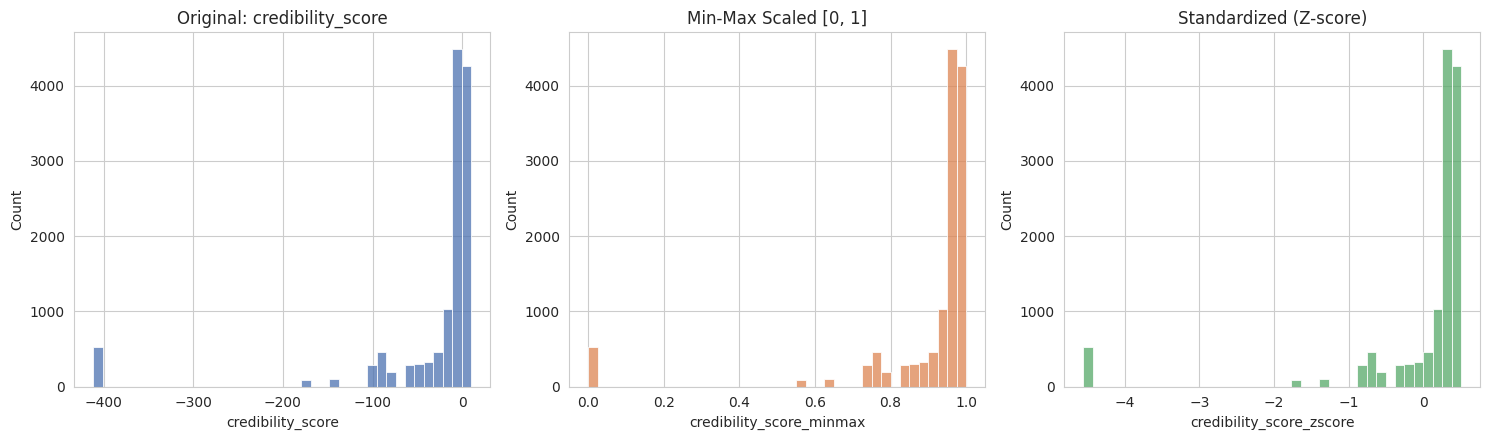

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(df['credibility_score'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Original: credibility_score')

sns.histplot(df['credibility_score_minmax'], bins=40, ax=axes[1], color='#DD8452')
axes[1].set_title('Min-Max Scaled [0, 1]')

sns.histplot(df['credibility_score_zscore'], bins=40, ax=axes[2], color='#55A868')
axes[2].set_title('Standardized (Z-score)')
plt.tight_layout()
plt.show()

**Comment / Observation:** Scaling preserves the underlying
**shape/skew** of the distribution — only the axis range changes. Min-Max
compresses everything into `[0, 1]`, while standardization centers the
data at 0 with unit variance; this confirms both scalers were applied
correctly and are ready for downstream modeling.

## 11. Final Summary (Post Feature-Engineering)

In [20]:
final_summary = pd.DataFrame({
    'Metric': [
        'Final rows', 'Final columns', 'Original columns', 'Engineered features added',
        'Scaled feature columns added', 'Missing values', 'Duplicate ids',
        'Label classes', 'Splits preserved'
    ],
    'Value': [
        df.shape[0], df.shape[1], 14, len(new_feats),
        len(scale_cols) * 2, int(df.isna().sum().sum()), int(df.duplicated(subset=['id']).sum()),
        df['label'].nunique(), df['split'].nunique()
    ]
})
print(final_summary.to_string(index=False))

print("\nFinal column list:")
print(list(df.columns))

                      Metric  Value
                  Final rows  12789
               Final columns     41
            Original columns     14
   Engineered features added      6
Scaled feature columns added     20
              Missing values      0
               Duplicate ids      0
               Label classes      6
            Splits preserved      3

Final column list:
['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_c', 'false_c', 'half_true_c', 'mostly_true_c', 'pants_fire_c', 'context', 'split', 'statement_char_len', 'statement_word_count', 'avg_word_length', 'total_history_count', 'credibility_score', 'is_true', 'barely_true_c_minmax', 'false_c_minmax', 'half_true_c_minmax', 'mostly_true_c_minmax', 'pants_fire_c_minmax', 'statement_char_len_minmax', 'statement_word_count_minmax', 'avg_word_length_minmax', 'total_history_count_minmax', 'credibility_score_minmax', 'barely_true_c_zscore', 'false_c_zscore', 'half_true_c_zscore', 'mo

**Comment / Observation:** The pipeline has taken the raw 14-column
LIAR `.tsv` files through cleaning, null handling, feature engineering,
and dual scaling to produce a fully numeric-ready, leak-free (features
derived from historical counts / text only, not the current label,
except the explicit `is_true` target) dataset with zero missing values
and no duplicate ids — ready for modeling.

## 12. Final Engineered Dataset

In [21]:
df.head(10)

           id        label                                                                                                                                                        statement                                    subject                 speaker                   job_title      state         party  barely_true_c  false_c  half_true_c  mostly_true_c  pants_fire_c                                   context  split  statement_char_len  statement_word_count  avg_word_length  total_history_count  credibility_score  is_true  barely_true_c_minmax  false_c_minmax  half_true_c_minmax  mostly_true_c_minmax  pants_fire_c_minmax  statement_char_len_minmax  statement_word_count_minmax  avg_word_length_minmax  total_history_count_minmax  credibility_score_minmax  barely_true_c_zscore  false_c_zscore  half_true_c_zscore  mostly_true_c_zscore  pants_fire_c_zscore  statement_char_len_zscore  statement_word_count_zscore  avg_word_length_zscore  total_history_count_zscore  credibility_score_zscore

In [22]:
output_path = '/mnt/user-data/outputs/liar_engineered_dataset.csv'
df.to_csv(output_path, index=False)
print(f"Final engineered dataset saved to: {output_path}")
print(f"Shape: {df.shape}")

Final engineered dataset saved to: /mnt/user-data/outputs/liar_engineered_dataset.csv
Shape: (12789, 41)


**Comment / Observation:** The final engineered dataset combines all
three original splits (tagged via the `split` column so `train`/`valid`/
`test` can be filtered back out at any time), contains the original raw
columns, the new engineered features, and both Min-Max and standardized
versions of every numeric feature — a single, analysis-ready CSV.